# CICIDS2017 Tailored Preprocessing for Sequence Models

This notebook builds a production-ready preprocessing pipeline for CICIDS2017 CSV files and exports data in **(Batch, Timesteps, Features)** format.

Main goals:
- Analyze raw files and validate schema consistency
- Clean `Infinity` / `NaN` artifacts and fix duplicate feature names
- Normalize labels and encode classes
- Scale numeric features without data leakage
- Build sequence tensors for time-aware models (RNN/LSTM/GRU/Transformer/ESN)
- Export reproducible training artifacts

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.utils.class_weight import compute_class_weight

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# ---------------------------
# Configuration
# ---------------------------
DATA_DIR = Path('MachineLearningCSV/MachineLearningCVE')
# Alternative source if you want to use generated labeled flows:
# DATA_DIR = Path('GeneratedLabelledFlows/TrafficLabelling')

OUTPUT_DIR = Path('artifacts/preprocessed_sequences')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TIMESTEPS = 20
STRIDE = 5
MIN_NON_NULL_RATIO = 0.60  # Drop columns with too many missing values
RANDOM_SEED = 42

csv_files = sorted(DATA_DIR.glob('*.csv'))
if not csv_files:
    raise FileNotFoundError(f'No CSV files found in {DATA_DIR.resolve()}')

print(f'Using data directory: {DATA_DIR.resolve()}')
print(f'CSV files discovered: {len(csv_files)}')
for p in csv_files:
    print(' -', p.name)

Using data directory: /home/sammarv/x-edge-esn/MachineLearningCSV/MachineLearningCVE
CSV files discovered: 8
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv


In [3]:
def normalize_column_name(name: str) -> str:
    """Normalize feature names to safe snake_case-like format."""
    name = name.strip()
    name = name.replace('/', '_per_')
    name = name.replace('-', '_')
    name = re.sub(r'\s+', '_', name)
    name = re.sub(r'[^0-9a-zA-Z_]', '', name)
    name = re.sub(r'_+', '_', name)
    return name.strip('_')


def make_unique(names: list[str]) -> list[str]:
    """Ensure duplicate columns get deterministic suffixes (_dup1, _dup2, ...)."""
    counts = Counter()
    result = []
    for n in names:
        counts[n] += 1
        if counts[n] == 1:
            result.append(n)
        else:
            result.append(f'{n}_dup{counts[n]-1}')
    return result


def normalize_label(raw: str) -> str:
    """Normalize label strings (including malformed unicode separators)."""
    text = str(raw).strip()
    text = text.replace('�', '-')
    text = re.sub(r'\s+', ' ', text)
    text = text.replace(' - ', '-')
    return text


def load_one_csv(path: Path) -> pd.DataFrame:
    """Load one raw CSV, normalize schema, and attach source file metadata."""
    df = pd.read_csv(path, low_memory=False)
    normalized = [normalize_column_name(c) for c in df.columns]
    df.columns = make_unique(normalized)

    if 'Label' not in df.columns:
        raise ValueError(f'Missing Label column in {path.name}')

    df['Label'] = df['Label'].map(normalize_label)
    df['source_file'] = path.name
    return df

In [4]:
# ---------------------------
# File-level profiling (tailored analysis)
# ---------------------------
profiles = []
header_hashes = {}

for path in csv_files:
    # Read only header to verify schema consistency before full load.
    header_df = pd.read_csv(path, nrows=0)
    normalized_cols = make_unique([normalize_column_name(c) for c in header_df.columns])
    header_hashes[path.name] = hash(tuple(normalized_cols))

    tmp = load_one_csv(path)
    label_counts = tmp['Label'].value_counts().to_dict()
    profiles.append({
        'file': path.name,
        'rows': int(tmp.shape[0]),
        'columns': int(tmp.shape[1]),
        'labels': label_counts,
    })

profile_df = pd.DataFrame([
    {
        'file': p['file'],
        'rows': p['rows'],
        'columns': p['columns'],
        'n_labels': len(p['labels'])
    }
    for p in profiles
])

print('Schema hashes (should typically match):')
display(pd.Series(header_hashes, name='header_hash'))

print('File profile:')
display(profile_df.sort_values('rows', ascending=False))

print('Per-file label distributions:')
for p in profiles:
    print(f"\n{p['file']}")
    for k, v in sorted(p['labels'].items(), key=lambda x: x[1], reverse=True):
        print(f'  {k}: {v}')

Schema hashes (should typically match):


Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv               79493233559195836
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv           79493233559195836
Friday-WorkingHours-Morning.pcap_ISCX.csv                      79493233559195836
Monday-WorkingHours.pcap_ISCX.csv                              79493233559195836
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv    79493233559195836
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv         79493233559195836
Tuesday-WorkingHours.pcap_ISCX.csv                             79493233559195836
Wednesday-workingHours.pcap_ISCX.csv                           79493233559195836
Name: header_hash, dtype: int64

File profile:


,file,rows,columns,n_labels
7,Wednesday-workingHours.pcap_ISCX.csv,692703,80,6
3,Monday-WorkingHours.pcap_ISCX.csv,529918,80,1
6,Tuesday-WorkingHours.pcap_ISCX.csv,445909,80,3
4,Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,288602,80,2
1,Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,286467,80,2
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745,80,2
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,191033,80,2
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv,170366,80,4


Per-file label distributions:

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  DDoS: 128027
  BENIGN: 97718

Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  PortScan: 158930
  BENIGN: 127537

Friday-WorkingHours-Morning.pcap_ISCX.csv
  BENIGN: 189067
  Bot: 1966

Monday-WorkingHours.pcap_ISCX.csv
  BENIGN: 529918

Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  BENIGN: 288566
  Infiltration: 36

Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  BENIGN: 168186
  Web Attack-Brute Force: 1507
  Web Attack-XSS: 652
  Web Attack-Sql Injection: 21

Tuesday-WorkingHours.pcap_ISCX.csv
  BENIGN: 432074
  FTP-Patator: 7938
  SSH-Patator: 5897

Wednesday-workingHours.pcap_ISCX.csv
  BENIGN: 440031
  DoS Hulk: 231073
  DoS GoldenEye: 10293
  DoS slowloris: 5796
  DoS Slowhttptest: 5499
  Heartbleed: 11


In [5]:
# ---------------------------
# Global dataframe build and cleaning
# ---------------------------
frames = [load_one_csv(path) for path in csv_files]
df = pd.concat(frames, ignore_index=True)

print('Raw shape:', df.shape)

# Separate metadata and target from feature matrix.
target_col = 'Label'
meta_cols = ['source_file']
feature_cols = [c for c in df.columns if c not in [target_col, *meta_cols]]

# Coerce all features to numeric: invalid values become NaN and will be handled below.
for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Replace +/- inf created by divisions in flow features (e.g., bytes/s).
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)

missing_ratio = df[feature_cols].isna().mean()
keep_cols = missing_ratio[missing_ratio <= (1 - MIN_NON_NULL_RATIO)].index.tolist()
drop_cols = sorted(set(feature_cols) - set(keep_cols))

if drop_cols:
    print(f'Dropping {len(drop_cols)} high-missing columns')
else:
    print('No high-missing columns dropped')

feature_cols = keep_cols

# Median imputation is robust to extreme heavy-tail traffic values.
medians = df[feature_cols].median(numeric_only=True)
df[feature_cols] = df[feature_cols].fillna(medians)

# Remove constant features that add no information.
nunique = df[feature_cols].nunique(dropna=False)
constant_cols = nunique[nunique <= 1].index.tolist()
if constant_cols:
    feature_cols = [c for c in feature_cols if c not in constant_cols]
    print(f'Removed constant features: {len(constant_cols)}')

print('Clean shape:', df[[*feature_cols, target_col, *meta_cols]].shape)
print('Feature count after cleaning:', len(feature_cols))
print('Global label distribution:')
display(df[target_col].value_counts())

Raw shape: (2830743, 80)
No high-missing columns dropped
Removed constant features: 8
Clean shape: (2830743, 72)
Feature count after cleaning: 70
Global label distribution:


Label
BENIGN                      2273097
DoS Hulk                     231073
PortScan                     158930
DDoS                         128027
DoS GoldenEye                 10293
FTP-Patator                    7938
SSH-Patator                    5897
DoS slowloris                  5796
DoS Slowhttptest               5499
Bot                            1966
Web Attack-Brute Force         1507
Web Attack-XSS                  652
Infiltration                     36
Web Attack-Sql Injection         21
Heartbleed                       11
Name: count, dtype: int64

## Visual Analytics (Tailored EDA)

The plots below provide a compact visual diagnosis of class imbalance, file composition, missingness, and feature spread after cleaning.

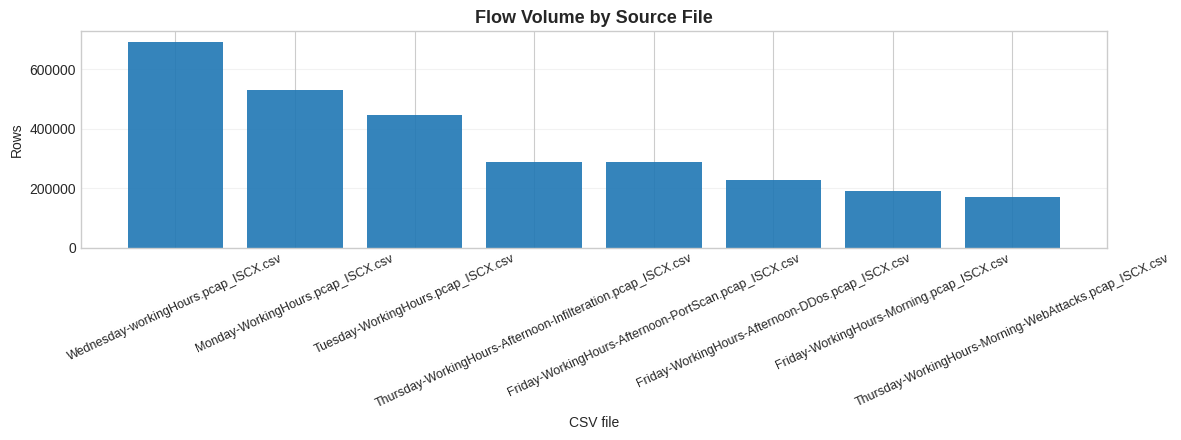

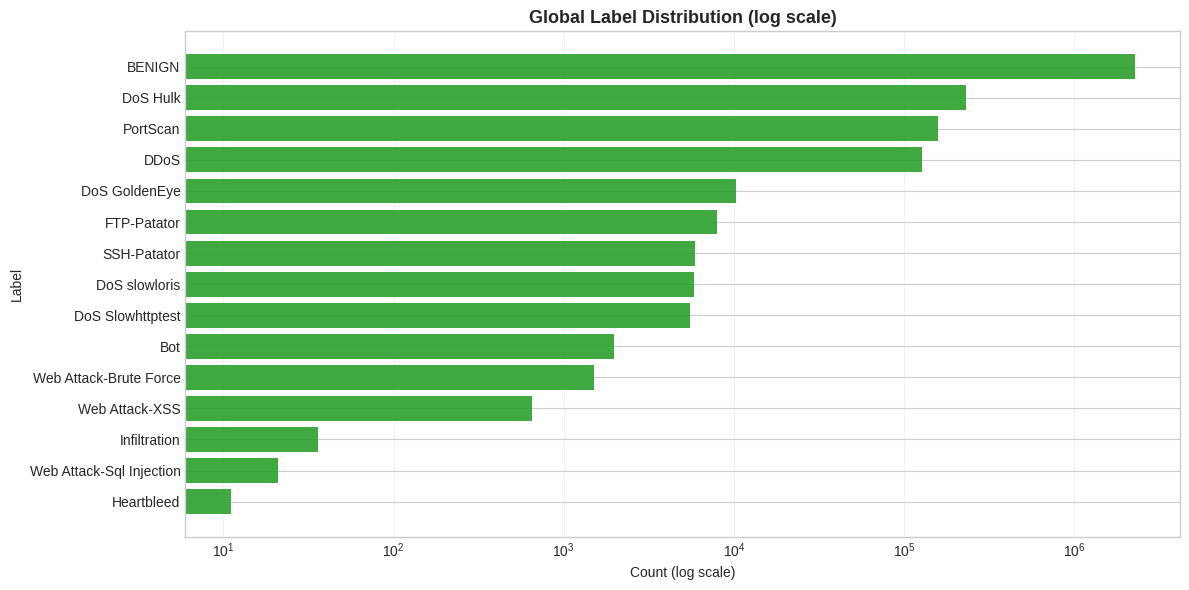

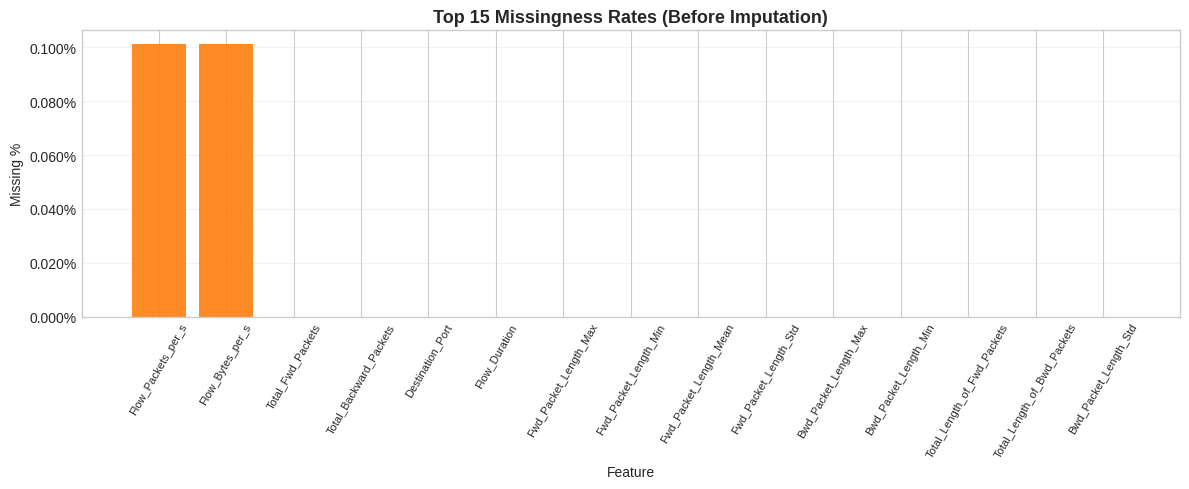

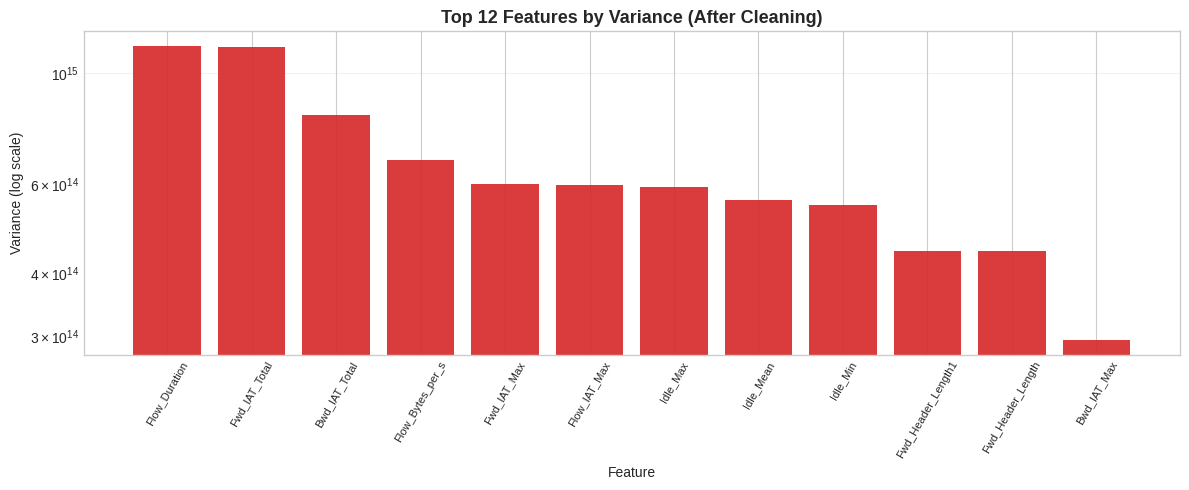

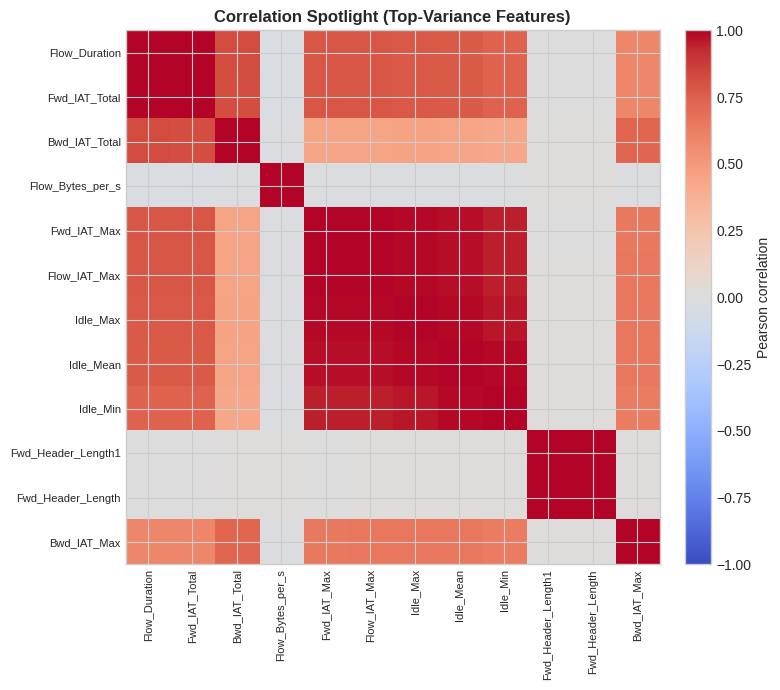

In [6]:
# ---------------------------
# Visual analytics
# ---------------------------

# 1) Rows by source file
rows_by_file = profile_df.sort_values('rows', ascending=False).copy()
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(rows_by_file['file'], rows_by_file['rows'], color='#1f77b4', alpha=0.9)
ax.set_title('Flow Volume by Source File', fontsize=13, weight='bold')
ax.set_ylabel('Rows')
ax.set_xlabel('CSV file')
ax.tick_params(axis='x', rotation=25, labelsize=9)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# 2) Global label distribution (log scale helps show minority attacks)
label_counts = df[target_col].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(label_counts.index, label_counts.values, color='#2ca02c', alpha=0.9)
ax.set_xscale('log')
ax.set_title('Global Label Distribution (log scale)', fontsize=13, weight='bold')
ax.set_xlabel('Count (log scale)')
ax.set_ylabel('Label')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

# 3) Missingness before imputation: top 15 features
missing_top = missing_ratio.sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(missing_top.index, missing_top.values * 100, color='#ff7f0e', alpha=0.9)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_title('Top 15 Missingness Rates (Before Imputation)', fontsize=13, weight='bold')
ax.set_ylabel('Missing %')
ax.set_xlabel('Feature')
ax.tick_params(axis='x', rotation=60, labelsize=8)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# 4) Post-cleaning feature spread: top 12 by variance
feature_variance = df[feature_cols].var().sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(feature_variance.index, feature_variance.values, color='#d62728', alpha=0.9)
ax.set_yscale('log')
ax.set_title('Top 12 Features by Variance (After Cleaning)', fontsize=13, weight='bold')
ax.set_ylabel('Variance (log scale)')
ax.set_xlabel('Feature')
ax.tick_params(axis='x', rotation=60, labelsize=8)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# 5) Correlation spotlight on highest-variance features
corr_features = feature_variance.index.tolist()
corr_mat = df[corr_features].corr().values
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_mat, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_features)))
ax.set_yticks(range(len(corr_features)))
ax.set_xticklabels(corr_features, rotation=90, fontsize=8)
ax.set_yticklabels(corr_features, fontsize=8)
ax.set_title('Correlation Spotlight (Top-Variance Features)', fontsize=12, weight='bold')
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson correlation', rotation=90)
plt.tight_layout()
plt.show()

In [10]:
# ---------------------------
# Leakage-aware split by source file (chronological day order)
# ---------------------------
order_map = {
    'Monday': 1,
    'Tuesday': 2,
    'Wednesday': 3,
    'Thursday': 4,
    'Friday': 5,
}

def day_rank(name: str) -> tuple[int, str]:
    for day, rank in order_map.items():
        if day.lower() in name.lower():
            return (rank, name)
    return (99, name)

ordered_files = sorted(df['source_file'].unique(), key=day_rank)
n_files = len(ordered_files)

train_files = ordered_files[: max(1, int(round(n_files * 0.60)))]
val_files = ordered_files[len(train_files): len(train_files) + max(1, int(round(n_files * 0.20)))]
test_files = [f for f in ordered_files if f not in train_files and f not in val_files]

if not test_files:
    test_files = val_files[-1:]
    val_files = val_files[:-1]

print('Train files:', train_files)
print('Val files  :', val_files)
print('Test files :', test_files)

train_df = df[df['source_file'].isin(train_files)].copy()
val_df = df[df['source_file'].isin(val_files)].copy()
test_df = df[df['source_file'].isin(test_files)].copy()

# Fit label space on all observed labels to support file-based splits where
# some attack classes may appear only in validation/test days.
all_classes = np.array(sorted(df[target_col].unique()))
label_encoder = LabelEncoder()
label_encoder.fit(all_classes)

y_train = label_encoder.transform(train_df[target_col])
y_val = label_encoder.transform(val_df[target_col])
y_test = label_encoder.transform(test_df[target_col])

# RobustScaler handles outliers better than StandardScaler on traffic features.
scaler = RobustScaler()
X_train = scaler.fit_transform(train_df[feature_cols])
X_val = scaler.transform(val_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])

print('Tabular shapes (before sequencing):')
print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val  :', X_val.shape, 'y_val  :', y_val.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape)

Train files: ['Monday-WorkingHours.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv']
Val files  : ['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv']
Test files : ['Friday-WorkingHours-Morning.pcap_ISCX.csv']
Tabular shapes (before sequencing):
X_train: (2127498, 70) y_train: (2127498,)
X_val  : (512212, 70) y_val  : (512212,)
X_test : (191033, 70) y_test : (191033,)


In [11]:
# ---------------------------
# Sequence builder: (Batch, Timesteps, Features)
# ---------------------------
def make_sequences_by_file(frame: pd.DataFrame, x_2d: np.ndarray, y_1d: np.ndarray, timesteps: int, stride: int) -> tuple[np.ndarray, np.ndarray]:
    """Build windows within each source file to avoid crossing file boundaries."""
    X_seq_list = []
    y_seq_list = []

    start_idx = 0
    for src_file, part in frame.groupby('source_file', sort=False):
        part_len = len(part)
        part_X = x_2d[start_idx: start_idx + part_len]
        part_y = y_1d[start_idx: start_idx + part_len]
        start_idx += part_len

        if part_len < timesteps:
            continue

        for i in range(0, part_len - timesteps + 1, stride):
            window_X = part_X[i:i + timesteps]
            # Assign sequence label as label of final timestep (causal setup).
            window_y = part_y[i + timesteps - 1]
            X_seq_list.append(window_X)
            y_seq_list.append(window_y)

    if not X_seq_list:
        raise ValueError('No sequences generated. Reduce TIMESTEPS or STRIDE.')

    return np.stack(X_seq_list), np.array(y_seq_list, dtype=np.int64)


X_train_seq, y_train_seq = make_sequences_by_file(train_df, X_train, y_train, TIMESTEPS, STRIDE)
X_val_seq, y_val_seq = make_sequences_by_file(val_df, X_val, y_val, TIMESTEPS, STRIDE)
X_test_seq, y_test_seq = make_sequences_by_file(test_df, X_test, y_test, TIMESTEPS, STRIDE)

print('Sequence tensor shapes:')
print('X_train_seq:', X_train_seq.shape, 'y_train_seq:', y_train_seq.shape)
print('X_val_seq  :', X_val_seq.shape, 'y_val_seq  :', y_val_seq.shape)
print('X_test_seq :', X_test_seq.shape, 'y_test_seq :', y_test_seq.shape)

Sequence tensor shapes:
X_train_seq: (425482, 20, 70) y_train_seq: (425482,)
X_val_seq  : (102436, 20, 70) y_val_seq  : (102436,)
X_test_seq : (38203, 20, 70) y_test_seq : (38203,)


In [12]:
# ---------------------------
# Export artifacts
# ---------------------------
np.save(OUTPUT_DIR / 'X_train_seq.npy', X_train_seq)
np.save(OUTPUT_DIR / 'y_train_seq.npy', y_train_seq)
np.save(OUTPUT_DIR / 'X_val_seq.npy', X_val_seq)
np.save(OUTPUT_DIR / 'y_val_seq.npy', y_val_seq)
np.save(OUTPUT_DIR / 'X_test_seq.npy', X_test_seq)
np.save(OUTPUT_DIR / 'y_test_seq.npy', y_test_seq)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_seq),
    y=y_train_seq
)
class_weight_map = {int(k): float(v) for k, v in zip(np.unique(y_train_seq), class_weights)}

metadata = {
    'timesteps': TIMESTEPS,
    'stride': STRIDE,
    'n_features': int(X_train_seq.shape[-1]),
    'feature_names': feature_cols,
    'classes': list(label_encoder.classes_),
    'class_weight_map': class_weight_map,
    'train_files': train_files,
    'val_files': val_files,
    'test_files': test_files,
    'shapes': {
        'X_train_seq': list(X_train_seq.shape),
        'y_train_seq': list(y_train_seq.shape),
        'X_val_seq': list(X_val_seq.shape),
        'y_val_seq': list(y_val_seq.shape),
        'X_test_seq': list(X_test_seq.shape),
        'y_test_seq': list(y_test_seq.shape)
    }
}

with open(OUTPUT_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print(f'Artifacts written to: {OUTPUT_DIR.resolve()}')
print('Saved files:')
for p in sorted(OUTPUT_DIR.glob('*')):
    print(' -', p.name)

Artifacts written to: /home/sammarv/x-edge-esn/artifacts/preprocessed_sequences
Saved files:
 - X_test_seq.npy
 - X_train_seq.npy
 - X_val_seq.npy
 - metadata.json
 - y_test_seq.npy
 - y_train_seq.npy
 - y_val_seq.npy


## Notes for Model Integration

- Input tensor format is exactly **(Batch, Timesteps, Features)**.
- Target format is a 1D integer vector aligned to each sequence (`y_*_seq`).
- Class names are available in `metadata.json -> classes`.
- Adjust `TIMESTEPS` and `STRIDE` to trade off temporal context vs dataset size.
- For strict real-time pipelines, keep the sequence label as last timestep label (already implemented).

## Dataset Characteristics

- **Total samples**: 2,830,743 flows across 8 daily CSV files.
- **Schema consistency**: identical header structure across files after normalization.
- **Raw columns**: 80 (including target and source metadata).
- **Final modeling features**: 70 numeric features after cleaning and constant-feature removal.
- **Dropped constant features**: 8.
- **Class cardinality**: 15 classes (BENIGN + 14 attack classes).
- **Class imbalance is severe**: BENIGN = 2,273,097 (~80.3% of all samples), while minority classes include Heartbleed = 11 and Web Attack-Sql Injection = 21.
- **Missingness profile**: very low overall; highest pre-imputation missing rates were concentrated in rate-based features (e.g., Flow_Packets_per_s, Flow_Bytes_per_s) and were around 0.1%.
- **Temporal/file-based split used** (leakage-aware):
  - Train rows: 2,127,498
  - Validation rows: 512,212
  - Test rows: 191,033
- **Sequence output format**: `(Batch, Timesteps, Features)` with `Timesteps = 20`, `Features = 70`.
  - Train sequences: 425,482
  - Validation sequences: 102,436
  - Test sequences: 38,203

These characteristics confirm that robust scaling, class weighting, and careful split strategy are necessary for stable model training on CICIDS2017.